# Pipeline EHBG-FACS · 04 · NCO por RL (POMO + Attention Model)

**Paradigma 4 — Attention Model entrenado por REINFORCE estilo POMO (GPU).**

Política neuronal entrenada **sin etiquetas**, con el costo de la ruta como recompensa y la estrategia **POMO**: N trayectorias desde nodos de inicio distintos + media como **línea base compartida**. Recompensa = costo **determinista** (tiempo nominal τ) → por eso es 'NCO determinista' y, evaluada bajo ξ, exhibe fragilidad ante la estocasticidad.

In [1]:
# === Configuración del entorno (ejecuta esta celda primero) =================
# Requiere: (a) el paquete `svrplab` (carpeta experiments/colab del repo de tesis)
#           (b) el repo oficial de SVRPBench (se clona solo en bootstrap.init()).
REPO_URL  = "https://github.com/AbrahamHub/TESIS-ANT"   # <-- EDITA si tu repo difiere
USE_DRIVE = True   # persistir banco/resultados/modelos en Google Drive (recomendado)

import os, sys, subprocess

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive no disponible (¿ejecutas local?):", e)

def _find_svrplab():
    cands = ["/content/drive/MyDrive/TESIS-ANT/experiments/colab",
             "/content/TESIS-ANT/experiments/colab",
             os.path.join(os.getcwd(), "experiments", "colab"),
             os.getcwd()]
    for c in cands:
        if os.path.isdir(os.path.join(c, "svrplab")):
            return c
    return None

_path = _find_svrplab()
if _path is None:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "/content/TESIS-ANT"], check=False)
    _path = "/content/TESIS-ANT/experiments/colab"
sys.path.insert(0, _path)
print("svrplab en:", _path)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "pandas",
                "matplotlib", "scikit-learn", "pillow", "tqdm"], check=False)
# torch ya viene en Colab. gurobipy solo se instala en el notebook del paradigma 1.

from svrplab import bootstrap, protocol, data, runner, metrics, viz
env   = bootstrap.init()        # GPU + repo oficial SVRPBench + rutas (Drive si está montado)
proto = protocol.DEFAULT
print("device:", env.device, "| raíz de artefactos:", env.paths.root)

Mounted at /content/drive
svrplab en: /content/TESIS-ANT/experiments/colab
[bootstrap] repo oficial ya presente en /content/drive/MyDrive/EHBG_FACS/svrpbench
[bootstrap] GPU detectada: Tesla T4 (14.6 GB) | torch 2.11.0+cu128 CUDA 12.8
[bootstrap] raíz de artefactos: /content/drive/MyDrive/EHBG_FACS
[bootstrap] results/ figures/ data/ listos | seed=12345 device=cuda
device: cuda | raíz de artefactos: /content/drive/MyDrive/EHBG_FACS


In [2]:
# === Configuración del experimento (IDÉNTICA en los 5 notebooks) ============
# Para garantizar el "piso parejo", TODOS los notebooks deben usar los MISMOS
# SIZES y N_INSTANCES: así resuelven exactamente el mismo banco de instancias.
SIZES       = [10, 20, 50]           # clientes. Extiende a [50,100,200,300] (ver notas).
N_INSTANCES = proto.instances_per_size   # 30 (rigor estadístico). Corrida rápida: pon 5.

bank = data.load_bank(env.paths.instances, SIZES, N_INSTANCES,
                      base_seed=proto.base_seed, capacity_mode=proto.capacity_mode, verbose=True)
print({s: len(v) for s, v in bank.items()}, "instancias por tamaño")

OR-Tools not available: No module named 'ortools'
[data] n=10: 30 instancias (cache) -> bank_n10_m30_s12345_binding.npz
[data] n=20: 30 instancias (cache) -> bank_n20_m30_s12345_binding.npz
[data] n=50: 30 instancias (cache) -> bank_n50_m30_s12345_binding.npz
{10: 30, 20: 30, 50: 30} instancias por tamaño


## Entrenar (POMO, GPU) e inferir
Entrenamiento autoregresivo con bonus de entropía y AMP en GPU. Aumenta `steps_per_size` para mayor calidad (más exigente en cómputo).

In [3]:
from svrplab.solvers.nco_rl import NCOReinforce
rl = NCOReinforce(train_sizes=(10,20), steps_per_size=1500, batch=64, embed_dim=128,
                  device=env.device, models_dir=env.paths.models, verbose=True)
df = runner.run_solver(rl, "nco-rl", bank, env, proto, verbose=True)
df

[nco-rl] n=10 paso 200/1500  costo_medio=3551.5
[nco-rl] n=10 paso 400/1500  costo_medio=2783.6
[nco-rl] n=10 paso 600/1500  costo_medio=2604.8
[nco-rl] n=10 paso 800/1500  costo_medio=2585.4
[nco-rl] n=10 paso 1000/1500  costo_medio=2676.1
[nco-rl] n=10 paso 1200/1500  costo_medio=2667.5
[nco-rl] n=10 paso 1400/1500  costo_medio=2659.9
[nco-rl] n=20 paso 200/1500  costo_medio=3963.1
[nco-rl] n=20 paso 400/1500  costo_medio=3916.0
[nco-rl] n=20 paso 600/1500  costo_medio=3937.8
[nco-rl] n=20 paso 800/1500  costo_medio=3958.9
[nco-rl] n=20 paso 1000/1500  costo_medio=3946.9
[nco-rl] n=20 paso 1200/1500  costo_medio=3917.4
[nco-rl] n=20 paso 1400/1500  costo_medio=3905.0
  [nco-rl] n=10 inst=0: E[c]=1902.5 E[c+Q]=2166.3 CVaR=2166.6 feas=0.00 veh=3 t=0.124s (wall 484.0s)
  [nco-rl] n=10 inst=1: E[c]=2198.5 E[c+Q]=4862.5 CVaR=4863.1 feas=0.00 veh=3 t=0.036s (wall 0.1s)
  [nco-rl] n=10 inst=2: E[c]=2731.5 E[c+Q]=3574.0 CVaR=3574.5 feas=0.00 veh=3 t=0.029s (wall 0.1s)
  [nco-rl] n=10 inst=3:

,solver,paradigm,size,instance,seed,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles
0,nco-rl,4,10,0,22345,NaN,1902.451407,2166.252096,2166.602435,0.0,20.0,0.120721,2.0,0.123587,483.734506,NaN,3
1,nco-rl,4,10,1,22346,NaN,2198.453549,4862.545461,4863.078968,0.0,60.0,0.126555,6.0,0.035732,483.734506,NaN,3
2,nco-rl,4,10,2,22347,NaN,2731.500482,3574.033471,3574.510154,0.0,20.0,0.141790,2.0,0.028907,483.734506,NaN,3
3,nco-rl,4,10,3,22348,NaN,2316.607653,4511.947025,4512.495965,0.0,50.0,0.140094,5.0,0.030342,483.734506,NaN,3
4,nco-rl,4,10,4,22349,NaN,1933.460889,3613.059730,3613.425872,0.0,30.0,0.137685,3.0,0.029548,483.734506,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,nco-rl,4,50,25,62370,NaN,5784.850717,16887.313136,16888.904707,0.0,58.0,0.260927,29.0,0.168314,483.734506,NaN,8
86,nco-rl,4,50,26,62371,NaN,6854.628631,14369.007986,14377.595979,0.0,34.0,6.204407,17.0,0.164869,483.734506,NaN,9
87,nco-rl,4,50,27,62372,NaN,8080.652041,15094.190202,15095.377132,0.0,38.0,0.268792,19.0,0.171720,483.734506,NaN,8
88,nco-rl,4,50,28,62373,NaN,5771.593803,13310.277332,13311.287711,0.0,40.0,0.231304,20.0,0.221093,483.734506,NaN,8


## Curva de entrenamiento y figuras

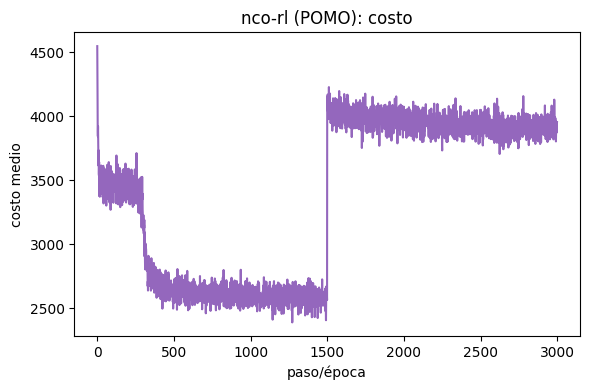

,solver,size,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles,expected_cost_std,expected_total_std,cvar_std
0,nco-rl,10,NaN,2341.374755,3676.521659,3677.553246,0.0,35.663333,1.005166,3.566333,0.032250,483.734506,NaN,3.033333,337.286704,667.785419,667.936216
1,nco-rl,20,NaN,3785.513439,6502.750905,6504.356694,0.0,34.666667,0.737595,6.933333,0.056097,483.734506,NaN,3.966667,529.044786,818.483358,819.176203
2,nco-rl,50,NaN,7039.795925,14473.088050,14497.845328,0.0,38.616333,1.799403,19.308167,0.183228,483.734506,NaN,8.133333,813.466213,1628.140721,1637.494098


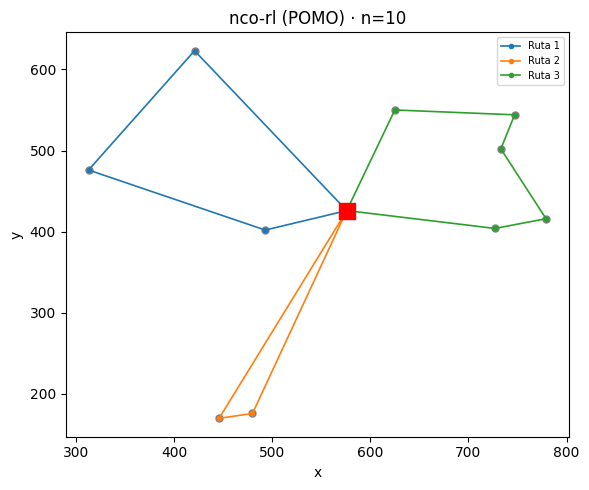

In [4]:
import matplotlib.pyplot as plt
if getattr(rl, "history", None):
    viz.plot_training_curve(rl.history, ylabel="costo medio", title="nco-rl (POMO): costo"); plt.show()
display(metrics.aggregate_by_size(df))
inst = bank[SIZES[0]][0]
sol = rl.solve(inst, num_realizations=proto.realizations)
viz.plot_routes(inst, sol.routes, title=f"nco-rl (POMO) · n={SIZES[0]}"); plt.show()

**Interpretación.** Bien entrenado, POMO se acerca al óptimo de costo y **supera a la NCO supervisada** (coherente con la literatura: RL > supervisado), pero al entrenarse en el problema determinista colapsa en factibilidad bajo la estocasticidad de las ventanas.